<a href="https://colab.research.google.com/github/camis08/IA_UC4/blob/main/Exercicios_regressao_entrega.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Criando a base de dados

In [4]:
#Carregue aqui a base de dados
df = pd.read_csv("base_logistica_entregas.csv")
df

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
...,...,...,...,...,...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim


# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

## Exercício 9
Quais variáveis são categóricas?

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

In [5]:
# Espaço para resolver a Parte A
df.head(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
5,6,34.4,17.3,2,301.96,baixo,forte_chuva,normal,zona_rural,168,sim
6,7,78.5,3.3,10,2048.23,medio,normal,expressa,bairro,196,sim
7,8,55.1,21.1,1,443.68,baixo,normal,normal,centro,157,sim
8,9,39.0,19.9,8,1349.17,medio,normal,expressa,centro,158,sim
9,10,32.0,1.7,6,982.79,medio,normal,normal,centro,122,sim


In [6]:
df.tail(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,191,17.3,2.8,4,1323.99,baixo,chuva,expressa,centro,61,nao
191,192,57.7,10.5,9,1929.33,medio,chuva,normal,bairro,212,sim
192,193,30.9,28.3,1,1558.34,medio,chuva,normal,zona_rural,175,sim
193,194,53.8,14.8,9,1268.27,medio,forte_chuva,normal,centro,235,sim
194,195,3.3,8.3,1,1504.90,medio,normal,normal,zona_rural,73,nao
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim
199,200,10.6,25.4,6,2290.93,medio,normal,normal,centro,133,sim


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    object 
 6   clima              200 non-null    object 
 7   tipo_entrega       200 non-null    object 
 8   regiao             200 non-null    object 
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 17.3+ KB


In [8]:
df.describe()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,40.757500,14.814500,5.950000,1343.555900,158.355000
std,57.879185,21.046217,8.801453,3.081392,718.343381,49.450437
min,1.000000,1.200000,0.300000,1.000000,35.170000,44.000000
25%,50.750000,25.075000,7.300000,3.000000,705.650000,126.000000
50%,100.500000,42.150000,14.050000,6.000000,1352.880000,158.500000
75%,150.250000,57.725000,22.800000,8.250000,1934.770000,189.250000
max,200.000000,79.600000,29.900000,11.000000,2489.780000,286.000000


In [9]:
df.isna().sum()

,0
id_pedido,0
distancia_km,0
peso_kg,0
qtd_itens,0
valor_pedido,0
trafego,0
clima,0
tipo_entrega,0
regiao,0
tempo_entrega_min,0


In [10]:
df.shape

(200, 11)

In [11]:
df.columns
# É 'tempo_entrega_min'

Index(['id_pedido', 'distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido',
       'trafego', 'clima', 'tipo_entrega', 'regiao', 'tempo_entrega_min',
       'atrasou'],
      dtype='object')

In [12]:
# distancia, quantidade itens, clima, região,tipo entrega

In [13]:
# trafego, clima, tipo entrega, região e atrasou

In [14]:
# porque é necessário transformar em dummies(binário)

# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    object 
 6   clima              200 non-null    object 
 7   tipo_entrega       200 non-null    object 
 8   regiao             200 non-null    object 
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 17.3+ KB


In [16]:
# Espaço para resolver a Parte B
tempo_medio_entrega = df["tempo_entrega_min"].mean()
tempo_medio_entrega

np.float64(158.355)

In [17]:
tempo_mediana_entrega = df["tempo_entrega_min"].median()
tempo_mediana_entrega

158.5

In [18]:
desvio_padrao = df["tempo_entrega_min"].std()
desvio_padrao

49.45043683849101

In [19]:
tempo_min = df["tempo_entrega_min"].min()
tempo_min

44

In [20]:
tempo_max = df["tempo_entrega_min"].max()
tempo_max

286

In [21]:
tempo_quartis = np.percentile(df["tempo_entrega_min"],[25,50,75])
tempo_quartis

array([126.  , 158.5 , 189.25])

In [22]:
print(df["tempo_entrega_min"].median())
print(df["tempo_entrega_min"].mean())

#significa que os dados estão bem distribuídos

158.5
158.355


In [23]:
print(df["tempo_entrega_min"].std())
# o tempo de entrega varia mais ou menos 50min em torno da média

49.45043683849101


In [24]:
z_score = (df["tempo_entrega_min"] - tempo_medio_entrega)/ desvio_padrao
z_score.sort_values(ascending=False)
#os valores estão entre -3 a 3, não há outlier no tempo de entrega

,tempo_entrega_min
21,2.581271
37,2.500382
24,2.298160
187,2.277937
95,2.257715
...,...
109,-2.090073
118,-2.090073
28,-2.251851
186,-2.251851


In [25]:
df.groupby("tipo_entrega")["tempo_entrega_min"].agg(
    ["count","mean"]
)

,count,mean
tipo_entrega,,
expressa,57,149.894737
normal,143,161.727273


In [26]:
df.groupby("trafego")["tempo_entrega_min"].agg(
    ["count","mean"]
)

,count,mean
trafego,,
alto,40,188.075000
baixo,67,135.119403
medio,93,162.311828


# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

Text(0.5, 1.0, 'Tempo Entrega')

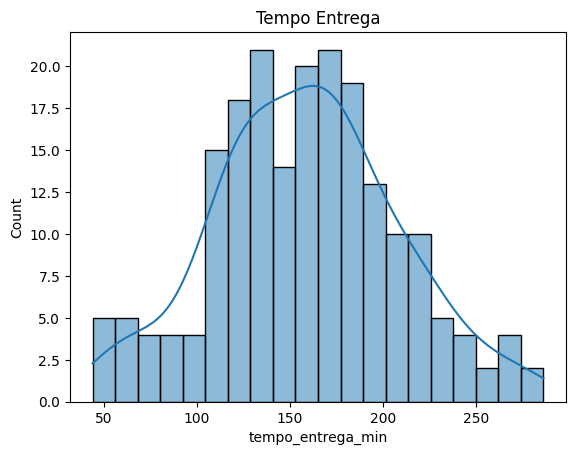

In [27]:
# Espaço para resolver a Parte C

sns.histplot(df["tempo_entrega_min"], bins = 20, kde = True)
plt.title("Tempo Entrega")

Text(0.5, 1.0, 'Tempo Entrega')

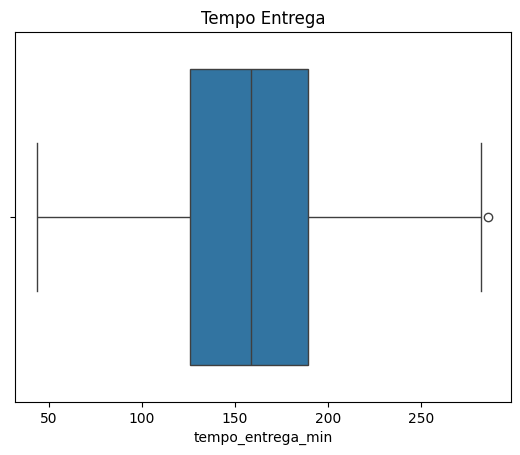

In [28]:
sns.boxplot(x ="tempo_entrega_min", data = df)
plt.title("Tempo Entrega")

Text(0.5, 1.0, 'Distância x Tempo Entrega')

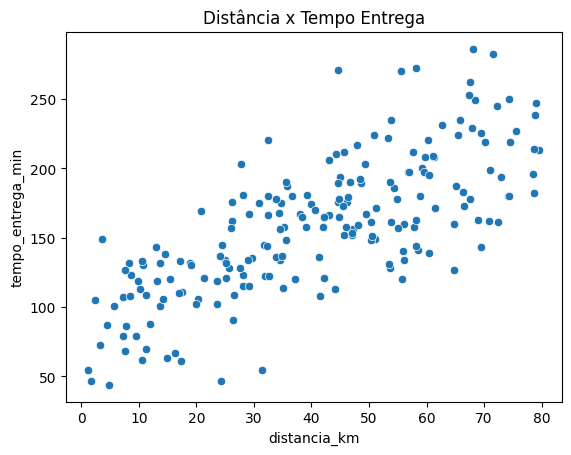

In [29]:
sns.scatterplot(x ="distancia_km", y="tempo_entrega_min", data = df)
plt.title("Distância x Tempo Entrega")

Text(0.5, 1.0, 'Peso x Tempo Entrega')

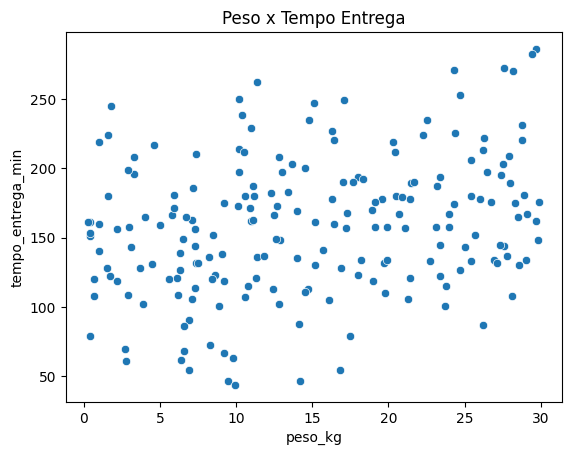

In [30]:
sns.scatterplot(x ="peso_kg", y="tempo_entrega_min", data = df)
plt.title("Peso x Tempo Entrega")

Text(0.5, 1.0, 'Quantidade Itens x Tempo Entrega')

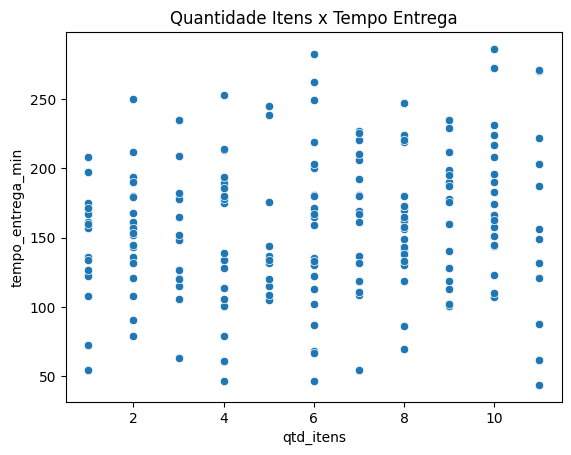

In [31]:
sns.scatterplot(x ="qtd_itens", y="tempo_entrega_min", data = df)
plt.title("Quantidade Itens x Tempo Entrega")

Text(0.5, 1.0, 'Trafego X Tempo Entrega')

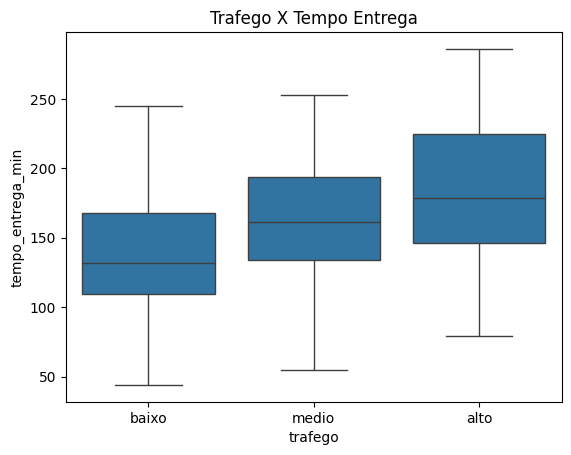

In [32]:
sns.boxplot(x ="trafego", y="tempo_entrega_min", data = df.sort_values(by = "tempo_entrega_min", ascending=True))
plt.title("Trafego X Tempo Entrega")

Text(0.5, 1.0, 'Clima X Tempo Entrega')

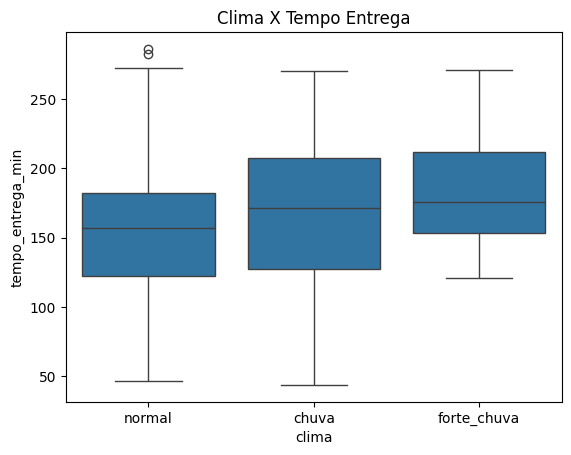

In [33]:
sns.boxplot(x ="clima", y="tempo_entrega_min", data = df)
plt.title("Clima X Tempo Entrega")

Text(0.5, 1.0, 'Tipo Entrega X Tempo Entrega')

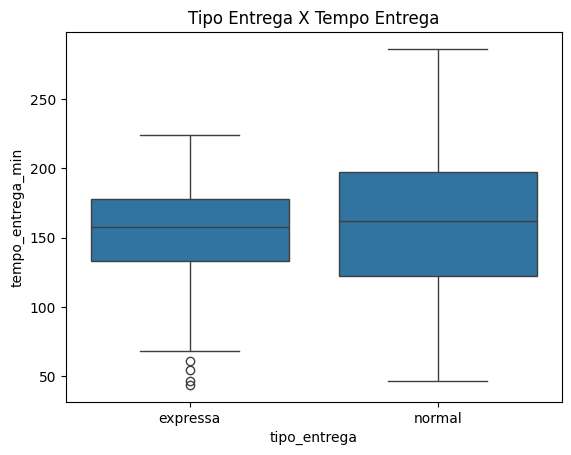

In [34]:
sns.boxplot(x ="tipo_entrega", y="tempo_entrega_min", data = df)
plt.title("Tipo Entrega X Tempo Entrega")

In [35]:
# visual foi a distancia_km, parece ser a maios relacionada ao tempo_entrega_min
# relação linear entre as duas vaariáveis

# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

In [36]:
# Espaço para resolver a Parte D
df_numerico = df[["distancia_km","peso_kg","qtd_itens","tempo_entrega_min","valor_pedido"]]
df_numerico

,distancia_km,peso_kg,qtd_itens,tempo_entrega_min,valor_pedido
0,56.0,16.4,9,160,2158.92
1,23.6,2.2,9,119,1431.91
2,18.9,19.7,5,132,464.30
3,44.6,29.9,5,176,1290.63
4,57.8,23.1,1,158,1899.66
...,...,...,...,...,...
195,51.2,10.9,1,171,1897.47
196,3.5,6.5,11,149,1356.59
197,59.8,12.8,10,208,2247.45
198,38.4,6.7,3,165,2369.26


In [37]:
df_numerico.corr()

,distancia_km,peso_kg,qtd_itens,tempo_entrega_min,valor_pedido
distancia_km,1.000000,-0.020853,-0.039094,0.743120,-0.073556
peso_kg,-0.020853,1.000000,0.016054,0.280642,-0.037019
qtd_itens,-0.039094,0.016054,1.000000,0.156666,0.132516
tempo_entrega_min,0.743120,0.280642,0.156666,1.000000,-0.045193
valor_pedido,-0.073556,-0.037019,0.132516,-0.045193,1.000000


Text(0.5, 1.0, 'Correlação')

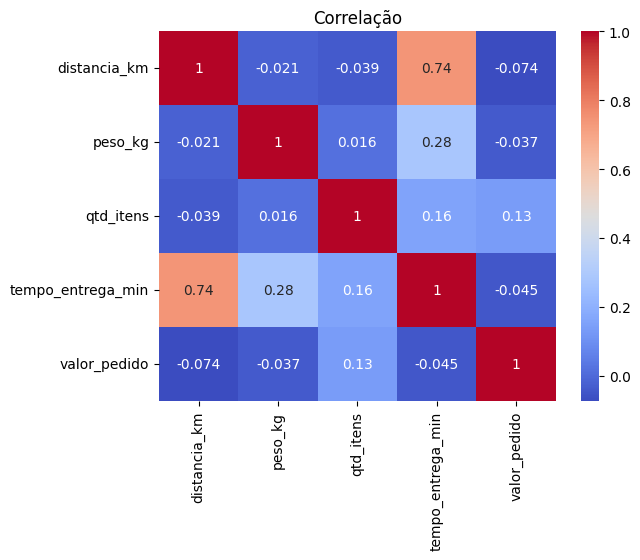

In [38]:
sns.heatmap(df_numerico.corr(), annot=True, cmap="coolwarm")
plt.title("Correlação")

In [39]:
# distancia_km que é 0,74

In [40]:
# valor pedido que é -0,045 que é o valor mais próximo de 0

In [41]:
# náo implica necessariamente em causalidade, pode existir outros fatores que  podem influenciar o tempo de entrega

In [42]:
# náo necessariamente, o valor_pedido pode acabar alterando em algum momento e a correläo aumentar

In [43]:
# sim, é a variável com a maior correlção positiva

In [44]:
# sim, mas a correlação é fraca

In [45]:
# distância, peso e quantidade de itens

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

In [46]:
# Espaço para resolver a Parte E
X = np.array(df["distancia_km"]).reshape(-1,1)
y = df["tempo_entrega_min"]

modelo = LinearRegression()
modelo.fit(X,y)
print(f"Modelo coeficiente angular: {modelo.coef_}")
print(f"Modelo intercepto: {modelo.intercept_}")

Modelo coeficiente angular: [1.74604322]
Modelo intercepto: 87.19064329209331


In [47]:
# X,y

Text(0.5, 1.0, 'Regressão Linear --> Tempo Entrega X Distância')

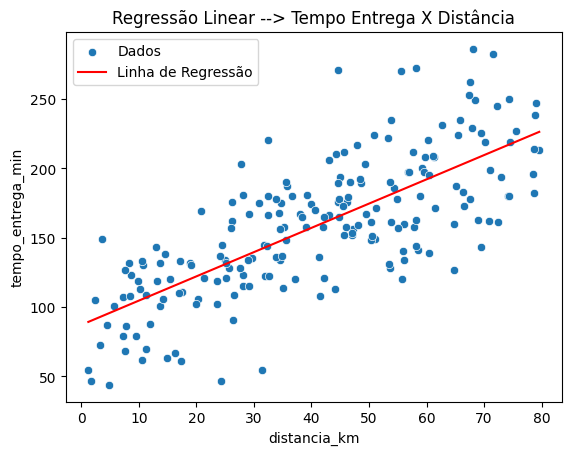

In [48]:
sns.scatterplot(x ="distancia_km", y="tempo_entrega_min", data = df, label = "Dados")
sns.lineplot(x=df["distancia_km"], y=modelo.predict(X), color ="red", label = "Linha de Regressão")
plt.title("Regressão Linear --> Tempo Entrega X Distância")

In [49]:
# Modelo coeficiente angular: [1.74604322]
    # cada 1km de distância o tempo de entrega aumenta 1,74min
# Modelo intercepto: 87.19064329209331
    #representa valor de tempo inicial de entrega quandro a distância é 0

In [50]:
y_pred = modelo.predict(X)
pd.DataFrame({
    "tempo_real": y,
    "tempo_previsto": y_pred,
    "erro": y - y_pred
})

,tempo_real,tempo_previsto,erro
0,160,184.969064,-24.969064
1,119,128.397263,-9.397263
2,132,120.190860,11.809140
3,176,165.064171,10.935829
4,158,188.111942,-30.111942
...,...,...,...
195,171,176.588056,-5.588056
196,149,93.301795,55.698205
197,208,191.604028,16.395972
198,165,154.238703,10.761297


In [51]:
mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 26.2844
RMSE: 33.0073
R2: 0.5522


In [52]:
# MAE(Erro medio absoluto): 26.2844
    # o modelo erra 26,28 min
# RMSE(Erro quadrático médio): 33.0073
    # o modelo erra +- 33min
# R2(Coeficiente de determinação): 0.5522
    # o modelo explica 55,22% variação dos dados em relação à media

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

Text(0.5, 0, 'distancia_km')

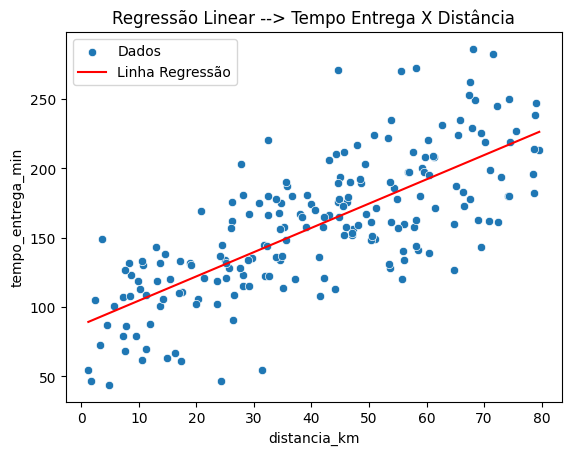

In [53]:
# Espaço para resolver a Parte F
sns.scatterplot(x =X.flatten(), y=y, label = "Dados")
sns.lineplot(x =X.flatten(), y=y_pred, color="red", label = "Linha Regressão")
plt.title("Regressão Linear --> Tempo Entrega X Distância")
plt.xlabel("distancia_km")

In [54]:
# sim, representa de acordo com os dados

In [55]:
# sim, existem alguns que estão distantes mas nem tanto

In [56]:
# podem ser outliers

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

In [57]:
# Espaço para resolver a Parte G
new_predict = modelo.predict([[5],[20],[60]])
new_predict

array([ 95.92085941, 122.11150777, 191.95323674])

In [58]:
# sim, o tempo de entrega aumenta conforme a distância aumnenta

In [59]:
# está ignorando as outras variáveis

# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [60]:
# Exemplo inicial para a Parte H

df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True

)

df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,False,True,False,True,False,False,False


In [61]:
# transforma as variáveis categóricas em dummies, varipáveis binárias, indicando presença ou ausença de cada categoria

In [62]:
# remover as primeira categoria de cada variável categórica, deixando as categorias restantes como variáveis dummies

In [63]:
# trafego_baixo	trafego_medio	clima_forte_chuva	clima_normal	tipo_entrega_normal	regiao_centro	regiao_zona_rural

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

In [64]:
# Espaço para resolver a Parte I
X = df_modelo.drop(columns=["id_pedido","tempo_entrega_min","atrasou"])
y = df_modelo["tempo_entrega_min"]

In [65]:
modelo_multivariado = LinearRegression()
modelo_multivariado.fit(X,y)

LinearRegression()

In [69]:
y_pred = modelo_multivariado.predict(X)

mae_multivariado = mean_absolute_error(y, y_pred)
rmse_multivariado = root_mean_squared_error(y, y_pred)
r2_multivariado = r2_score(y, y_pred)

print(f"MAE: {mae_multivariado:.2f}")
print(f"RMSE: {rmse_multivariado:.2f}")
print(f"R2: {r2_multivariado:.2f}")

MAE: 14.48
RMSE: 17.58
R2: 0.87


In [71]:
print(f"MAE: {mae_multivariado:.2f}")
print(f"RMSE: {rmse_multivariado:.2f}")
print(f"R2: {r2_multivariado:.2f}")

""" o modelo multivariado apresentou um erro absoluto médio menor do que o modelo simples,
apresentou um erro quadrático médio menor e um coefienciente de r2 maior, indicando que o modelo
multivariado tem um desempenho melhorna previsão de entreega
"""

MAE: 14.48
RMSE: 17.58
R2: 0.87


' o modelo multivariado apresentou um erro absoluto médio menor do que o modelo simples,\napresentou um erro quadrático médio menor e um coefienciente de r2 maior, indicando que o modelo \nmultivariado tem um desempenho melhorna previsão de entreega\n'

In [72]:
"""
distancia_k, a base do cálculo
trafego,  ajudou o modelo a ajustar o tempo para cima ou para baixo dependendo do fluxo
clima,  casos de chuva forte, que impactam diretamente a velocidade média das entregas
"""

'\ndistancia_k, a base do cálculo\ntrafego,  ajudou o modelo a ajustar o tempo para cima ou para baixo dependendo do fluxo\nclima,  casos de chuva forte, que impactam diretamente a velocidade média das entregas\n'

# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

In [75]:
# Espaço para resolver a Parte J
df_coeficiente = pd.DataFrame({
    "variavel": X.columns,
    "coeficiente": modelo_multivariado.coef_
}).sort_values(by="coeficiente",key=abs, ascending=False)
df_coeficiente

,variavel,coeficiente
4,trafego_baixo,-35.000253
6,clima_forte_chuva,28.839053
8,tipo_entrega_normal,25.284407
5,trafego_medio,-17.819863
10,regiao_zona_rural,14.674497
7,clima_normal,-12.477173
9,regiao_centro,-11.643316
2,qtd_itens,2.557247
0,distancia_km,1.801969
1,peso_kg,1.443045


In [78]:
df_ordenado = df_coeficiente.sort_values(by='coeficiente', ascending=False)
print(df_ordenado)

               variavel  coeficiente
6     clima_forte_chuva    28.839053
8   tipo_entrega_normal    25.284407
10    regiao_zona_rural    14.674497
2             qtd_itens     2.557247
0          distancia_km     1.801969
1               peso_kg     1.443045
3          valor_pedido     0.000152
9         regiao_centro   -11.643316
7          clima_normal   -12.477173
5         trafego_medio   -17.819863
4         trafego_baixo   -35.000253


In [80]:
"""
clima_forte_chuva
tipo_entrega_normal
regiao_zona_rural
qtd_itens
distancia_km
peso_kg
"""

'\nclima_forte_chuva \ntipo_entrega_normal\nregiao_zona_rural\nqtd_itens\ndistancia_km\npeso_kg\n'

In [79]:
"""
trafego_baixo
trafego_medio
clima_normal
regiao_centro
"""

'\ntrafego_baixo\ntrafego_medio\nclima_normal\nregiao_centro\n'

In [81]:
# cada 1 km extra, o modelo adiciona 1,80 minutos ao tempo de entrega, assumindo que todas as outras variáveis fiquem iguais

In [82]:
# se a entrega for expressa, ela é cerca de 25 minutos mais rápida

In [83]:
# trafego_baixo tira 35 minutos e o medio tira 17, o trafego_alto é o cenário mais demorado
# tráfego baixo em vez de alto economiza 35 minutos

In [84]:
# adiciona 28,83 minutos à previsão de entrega

In [85]:
# chuva forte e zona rural aumentem o tempo
# tráfego baixo e estar no centro (onde as distâncias internas
# costumam ser menores ou as vias melhores) diminuam o tempo


In [86]:
"""
distancia_km tivesse um sinal negativo, indicaria um problema nos dados, variáveis
muito parecidas "confundindo" o modelo ou amostra insuficiente de dados
"""

'\ndistancia_km tivesse um sinal negativo, indicaria um problema nos dados, variáveis \nmuito parecidas "confundindo" o modelo ou amostra insuficiente de dados\n'

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

In [87]:
# Espaço para resolver a Parte K
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [91]:
modelo_multivariado.fit(X_train, y_train)
y_pred = modelo_multivariado.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

MAE: 16.38
RMSE: 19.87
R2: 0.83


In [94]:
mae_treino = mean_absolute_error(y_train, modelo_multivariado.predict(X_train))
rmse_treino = root_mean_squared_error(y_train, modelo_multivariado.predict(X_train))
r2_treino = r2_score(y_train, modelo_multivariado.predict(X_train))

print(f"MAE: {mae_treino:.2f}")
print(f"RMSE: {rmse_treino:.2f}")
print(f"R2: {r2_treino:.2f}")

MAE: 13.84
RMSE: 16.85
R2: 0.88


In [95]:
"""
Se os erros MAE e RMSE no teste forem próximos aos erros do treino,
e o  R2  for similar, significa que ele aprendeu os padrões e
não apenas "decorou"
"""

'\nSe os erros MAE e RMSE no teste forem próximos aos erros do treino, \ne o  R2  for similar, significa que ele aprendeu os padrões e \nnão apenas "decorou"\n'

In [96]:
"""
quando o modelo tem um desempenho excelente no treino ou um desempenho muito
ruim no teste, indica que o modelo decorou ruídos e detalhes irrelevantes
dos dados de treino
"""

'\nquando o modelo tem um desempenho excelente no treino ou um desempenho muito\nruim no teste, indica que o modelo decorou ruídos e detalhes irrelevantes \ndos dados de treino\n'

In [97]:
"""
validação com dados reais recentes
monitoramento drift
tratamento outlier
segurança de dados
"""

'\nvalidação com dados reais recentes\nmonitoramento drift\ntratamento outlier\nsegurança de dados\n'

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

In [102]:
# Espaço para resolver a Parte L
meu_modelo = LinearRegression()
meu_modelo.fit(X,y)

df_meu_modelo = pd.DataFrame({
    "tempo_real": y,
    "tempo_previsto": meu_modelo.predict(X),
    "erro": y - meu_modelo.predict(X),
    "erro_absoluto": abs(y - meu_modelo.predict(X))
})
df_meu_modelo

,tempo_real,tempo_previsto,erro,erro_absoluto
0,160,176.483911,-16.483911,16.483911
1,119,120.276563,-1.276563,1.276563
2,132,129.190008,2.809992,2.809992
3,176,185.642420,-9.642420,9.642420
4,158,168.898363,-10.898363,10.898363
...,...,...,...,...
195,171,165.518146,5.481854,5.481854
196,149,120.079346,28.920654,28.920654
197,208,180.707174,27.292826,27.292826
198,165,141.578559,23.421441,23.421441


In [103]:
df_meu_modelo.sort_values(by="erro_absoluto", ascending=False).head(10)

,tempo_real,tempo_previsto,erro,erro_absoluto
114,203,157.935948,45.064052,45.064052
94,217,172.611102,44.388898,44.388898
45,169,127.128726,41.871274,41.871274
103,70,111.089568,-41.089568,41.089568
158,134,175.078913,-41.078913,41.078913
100,108,147.013586,-39.013586,39.013586
73,163,201.402406,-38.402406,38.402406
88,121,155.961727,-34.961727,34.961727
41,113,79.959924,33.040076,33.040076
139,210,176.969944,33.030056,33.030056


In [104]:
"""
acidentes, pneu furado, o cliente não estava em casa, não escutou
uma entrega em zona rural com chuva forte e tráfego alto simultaneamente,
onde o impacto real foi maior do que a soma das médias do modelo
"""

'\nacidentes, pneu furado, o cliente não estava em casa, não escutou\numa entrega em zona rural com chuva forte e tráfego alto simultaneamente, \nonde o impacto real foi maior do que a soma das médias do modelo\n'

In [105]:
"""
O modelo é altamente útil, com um erro médio de 14,48 minutos
Os fatores de maior impacto são tráfego baixo, chuva forte e entregas não-expressas
deve servir como suporte, e não ser usado sozinho, pois não prevê imprevistos graves
Para melhorar incluir GPS em tempo real, horários de pico e tipos de veículos
"""

'\nO modelo é altamente útil, com um erro médio de 14,48 minutos\nOs fatores de maior impacto são tráfego baixo, chuva forte e entregas não-expressas\ndeve servir como suporte, e não ser usado sozinho, pois não prevê imprevistos graves\nPara melhorar incluir GPS em tempo real, horários de pico e tipos de veículos\n'

# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [106]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.